In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Training the global operator on real-world data

### Stationary real-world dataset

The real-world data include a stationary 440 Hz signal.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



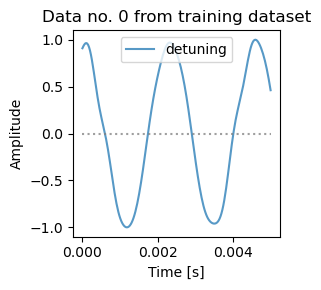

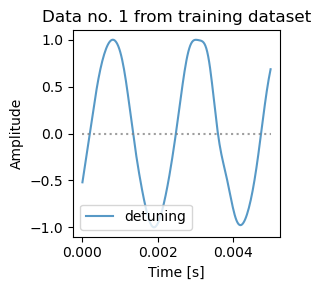

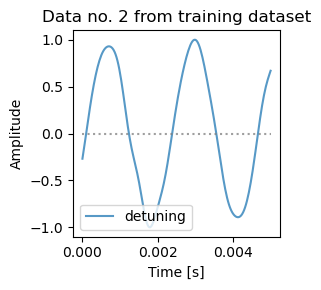

In [2]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir            = 'data/train_meas_g'
timeseries_ndim        = 1
timeseries_nsample     = 200
timestep               = 2.5e-5

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils.disp_dataset(dataset_dir, timeseries_nsample, timestep)

### Model instantiation

As in the synthetic case, the model is instantiated with 4 basis functions: a sine and a cosine, as well as 2 data-driven functions. We also set parameter $\tau=40$ to align with the synthetic example. Of course, as our real-world data feature a single oscillatory mode then the DMD-like global operator will identify only one complex pair of eigenvalues.

In [3]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model_cfg = care.detuning_config(

    timeseries_ndim     = timeseries_ndim,
    timeseries_nsample  = subtimeseries_nsample,
    timestep            = timestep,

    fun = {
        'poly_1' : 1,
        'poly_2' : 1,
        'poly_3' : 1,
        'poly_4' : 1,
        'sin'    : 2,
        'cos'    : 2
    },

    param_kernsize    = 40,
)

model = care.detuning(model_cfg)

### Model training

In [4]:
# --!--------------------------------------------------------------------------
# --! train all phases in one loop

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : 'data/train_meas_g',
    'transdatadir'          : 'data/train_meas_l',
    'mixdatadir'            : 'data/train_meas_mix',
    'timeseries_nsample'    : timeseries_nsample,
    'subtimeseries_nsample' : subtimeseries_nsample,
    'alphafun'              : None,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'isstaonly'             : True,
    'ismeanonly'            : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-8,
}

loss = []

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering dynamic mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file num

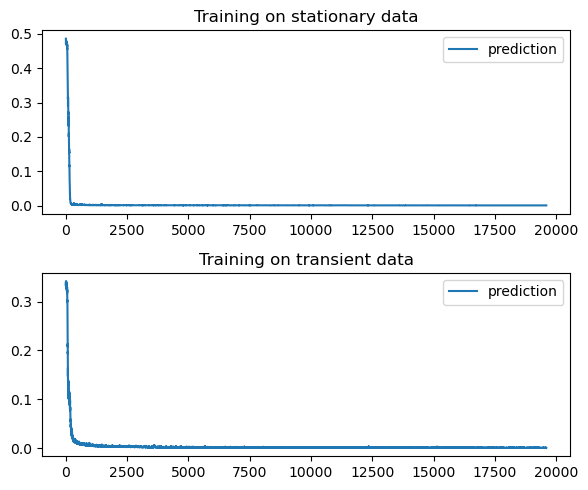

In [5]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    sta_stats = loss[0]
    dyn_stats = loss[2]

    plt.figure(figsize=(6, 5))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(sta_stats[0], label='prediction')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(dyn_stats[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.operator_sta.model.weight)

if savemod_on:
    torch.save(model, 'models/kind_meas.pt')

Parameter containing:
tensor([[-0.0210, -0.0663,  0.2215, -0.6386,  0.3260,  0.6510],
        [ 0.3178, -0.7791,  0.0733,  0.1787, -0.0199,  0.1302],
        [ 0.4146, -0.0670,  0.4666, -0.5320, -0.0444, -0.3210],
        [-0.7436, -0.4837,  0.6331, -0.0161, -0.2209,  0.0391],
        [-0.0178, -0.0322,  0.5573,  0.1268,  0.1731,  0.0425],
        [ 0.2812,  0.4629,  0.4059,  0.2318, -0.7682, -0.2363]])
